# A Multi-domain, Artifact-aware, and Explanation-integrated Universal Synthetic Image Detection

**Capstone Project — Final Notebook (Local GPU Execution)**

**Authors:** Tanvir Mahmud Prince, Eshan Agarwal

**Dataset:** FaceForensics++ from [HuggingFace](https://huggingface.co/datasets/Toonlink/Capstone)

---

## Notebook Structure
1. Imports, GPU setup & data download
2. Load & prepare dataset from HuggingFace
3. Dataset class & FFT helpers
4. Model definitions (SimpleCNN, FusionCNN, AttentionFusionCNN)
5. GPU-optimized training & evaluation
6. Train all 4 model variants
7. Results comparison table
8. Confusion matrices & loss curves
9. Grad-CAM explainability
10. Save results
11. Summary

## 1. Imports, Config, GPU Setup & Data Download from HuggingFace

In [18]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import json, random, warnings, sys, os, glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
)

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
FIG_DIR = OUTPUT_ROOT / 'figures'
METRIC_DIR = OUTPUT_ROOT / 'metrics'
CKPT_DIR = OUTPUT_ROOT / 'checkpoints'
for d in [FIG_DIR, METRIC_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# GPU detection
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True

scaler = GradScaler(enabled=(DEVICE == 'cuda'))
print(f'Mixed precision: {"ENABLED" if DEVICE == "cuda" else "DISABLED"}')

Device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Memory: 12.9 GB
Mixed precision: ENABLED


## 2. Load Dataset from Local Folders

Training images are in `train/REAL/` and `train/FAKE/`.
Testing images are in `test/REAL/` and `test/FAKE/`.

In [ ]:
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
train_fake_dir = PROJECT_ROOT / 'train' / 'FAKE'
train_real_dir = PROJECT_ROOT / 'train' / 'REAL'
test_fake_dir = PROJECT_ROOT / 'test' / 'FAKE'
test_real_dir = PROJECT_ROOT / 'test' / 'REAL'

print(f'Train FAKE: {len(list(train_fake_dir.glob("*.jpg")))} '
      f'| Train REAL: {len(list(train_real_dir.glob("*.jpg")))}')
print(f'Test  FAKE: {len(list(test_fake_dir.glob("*.jpg")))} '
      f'| Test  REAL: {len(list(test_real_dir.glob("*.jpg")))}')

Train FAKE: 50000 | Train REAL: 50000
Test  FAKE: 10000 | Test  REAL: 10000


In [ ]:
def to_fft_batch(images):
    """Batch FFT on GPU: (B,3,H,W) -> (B,1,H,W) log-magnitude."""
    g = images.mean(dim=1, keepdim=True)
    f = torch.fft.fft2(g)
    mag = torch.log(torch.abs(torch.fft.fftshift(f)) + 1e-8)
    B = mag.shape[0]
    mag = mag.view(B, -1)
    mag = (mag - mag.min(dim=1, keepdim=True).values) / (
        mag.max(dim=1, keepdim=True).values - mag.min(dim=1, keepdim=True).values + 1e-8
    )
    return mag.view(B, 1, images.shape[2], images.shape[3])


class FFImageDataset(Dataset):
    """Loads REAL/FAKE images from a list of (path, label) tuples."""
    def __init__(self, samples, image_size=128):
        self.samples = samples
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


MAX_PER_CLASS = 10000
IMAGE_SIZE = 128

def load_samples(fake_dir, real_dir, max_per_class=None):
    fake_paths = sorted([str(p) for p in Path(fake_dir).glob('*.jpg')])
    real_paths = sorted([str(p) for p in Path(real_dir).glob('*.jpg')])
    if max_per_class is not None:
        random.shuffle(fake_paths)
        random.shuffle(real_paths)
        fake_paths = fake_paths[:max_per_class]
        real_paths = real_paths[:max_per_class]
    samples = [(p, 1) for p in fake_paths] + [(p, 0) for p in real_paths]
    random.shuffle(samples)
    return samples

train_samples = load_samples(train_fake_dir, train_real_dir, max_per_class=MAX_PER_CLASS)
test_samples = load_samples(test_fake_dir, test_real_dir, max_per_class=MAX_PER_CLASS)

train_dataset = FFImageDataset(train_samples, image_size=IMAGE_SIZE)
test_dataset = FFImageDataset(test_samples, image_size=IMAGE_SIZE)

print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')
print(f'  Train REAL: {sum(1 for _,l in train_samples if l==0)} '
      f'| Train FAKE: {sum(1 for _,l in train_samples if l==1)}')
print(f'  Test  REAL: {sum(1 for _,l in test_samples if l==0)} '
      f'| Test  FAKE: {sum(1 for _,l in test_samples if l==1)}')

Train: 20000 | Test: 20000
  Train REAL: 10000 | Train FAKE: 10000
  Test  REAL: 10000 | Test  FAKE: 10000


In [ ]:
BATCH_SIZE = 488
EPOCHS = 16
NUM_WORKERS = 0 

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS
)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')
print(f'Samples per epoch: {len(train_dataset)}')

Train batches: 41 | Test batches: 41
Samples per epoch: 20000


## 3. Model Definitions

Four variants, same as the report.
- **Spatial CNN**: RGB-only baseline
- **Frequency FFT-CNN**: FFT magnitude-only baseline
- **Fusion (concat)**: Concatenates spatial + frequency branch outputs
- **Attention Fusion**: Learned attention-weighted fusion of both branches

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class _SmallBranch(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class FusionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial_branch = _SmallBranch(3)
        self.frequency_branch = _SmallBranch(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, img, fft):
        return self.classifier(torch.cat(
            (self.spatial_branch(img), self.frequency_branch(fft)), dim=1))


class _AttnBranch(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class AttentionFusionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.spatial_branch = _AttnBranch(3)
        self.frequency_branch = _AttnBranch(1)
        self.attention = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2), nn.Softmax(dim=1))
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, img, fft):
        s = self.spatial_branch(img)
        f = self.frequency_branch(fft)
        w = self.attention(torch.cat([s, f], dim=1))
        return self.classifier(
            w[:, 0].unsqueeze(1) * s + w[:, 1].unsqueeze(1) * f)

## 4. Training & Evaluation Utilities (GPU-optimized)

In [15]:
def get_logits(model, images, fft_images, model_name):
    if model_name in ('fusion', 'attention_fusion'):
        return model(images, fft_images)
    if model_name == 'frequency':
        return model(to_fft_batch(images))
    return model(images)

def make_model(model_name):
    if model_name == 'fusion':           return FusionCNN().to(DEVICE)
    if model_name == 'attention_fusion': return AttentionFusionCNN().to(DEVICE)
    if model_name == 'frequency':        return SimpleCNN(in_channels=1).to(DEVICE)
    return SimpleCNN(in_channels=3).to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion, model_name):
    model.train()
    total = 0.0
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        fft_images = to_fft_batch(images)
        labels = labels.float().view(-1, 1).to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = get_logits(model, images, fft_images, model_name)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, model_name):
    model.eval()
    total = 0.0
    preds, probs_all, labels_all = [], [], []
    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        fft_images = to_fft_batch(images)
        labels_t = labels.float().view(-1, 1).to(DEVICE, non_blocking=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = get_logits(model, images, fft_images, model_name)
            total += criterion(logits, labels_t).item()
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds.extend((probs > 0.5).astype(int).tolist())
        probs_all.extend(probs.tolist())
        labels_all.extend(labels.cpu().numpy().tolist())
    auc = roc_auc_score(labels_all, probs_all) if len(set(labels_all)) > 1 else float('nan')
    return {
        'loss': total / len(loader),
        'accuracy': float(accuracy_score(labels_all, preds)),
        'precision': float(precision_score(labels_all, preds, zero_division=0)),
        'recall': float(recall_score(labels_all, preds, zero_division=0)),
        'f1': float(f1_score(labels_all, preds, zero_division=0)),
        'roc_auc': float(auc) if not np.isnan(auc) else None,
        'confusion_matrix': confusion_matrix(labels_all, preds).tolist(),
    }


def plot_losses(train_losses, val_losses, out_path, title):
    plt.figure()
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Test')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(title); plt.legend(); plt.tight_layout()
    plt.savefig(out_path, dpi=120); plt.show(); plt.close()


def plot_confusion(cm, title, out_path):
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title); plt.colorbar()
    plt.xticks([0, 1], ['Real', 'Fake'])
    plt.yticks([0, 1], ['Real', 'Fake'])
    plt.xlabel('Predicted'); plt.ylabel('True')
    vmax = max(map(max, cm)) if cm else 1
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, str(cm[i][j]), ha='center', va='center',
                     color='white' if cm[i][j] > vmax/2 else 'black')
    plt.tight_layout(); plt.savefig(out_path, dpi=120); plt.show(); plt.close()

## 5. Train All Four Models

Each model trains for 10 epochs on a balanced subset from the HuggingFace dataset.
Expect ~70-85% accuracy range; anything near 100% or 50% would indicate a bug.

In [ ]:
def run_experiment(model_name, epochs=EPOCHS, lr=1e-3):
    print(f'\n{"="*60}\nTraining: {model_name.upper()}\n{"="*60}')
    model = make_model(model_name)
    param_count = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {param_count:,}')

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    test_losses = []
    best_f1 = 0.0

    for epoch in range(epochs):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, model_name)
        metrics = evaluate(model, test_loader, criterion, model_name)
        scheduler.step()

        train_losses.append(tr_loss)
        test_losses.append(metrics['loss'])

        if metrics['accuracy'] >= 0.98:
            print('  *** WARNING: Accuracy >= 98% - check for data leak or overfitting ***')
        if metrics['accuracy'] <= 0.52:
            print('  *** WARNING: Accuracy near chance level - check training ***')

        print(f'  Ep {epoch+1}/{epochs} | '
              f'tr={tr_loss:.4f} te={metrics["loss"]:.4f} | '
              f'acc={metrics["accuracy"]:.4f} prec={metrics["precision"]:.4f} '
              f'rec={metrics["recall"]:.4f} f1={metrics["f1"]:.4f} '
              f'auc={metrics["roc_auc"]}')

        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            torch.save(model.state_dict(), CKPT_DIR / f'{model_name}_best.pt')

    final = evaluate(model, test_loader, criterion, model_name)

    plot_losses(train_losses, test_losses,
                FIG_DIR / f'{model_name}_loss.png',
                f'{model_name} - Train/Test Loss')

    if final.get('confusion_matrix'):
        plot_confusion(final['confusion_matrix'],
                       FIG_DIR / f'{model_name}_cm.png',
                       f'{model_name} Confusion Matrix')

    with open(METRIC_DIR / f'{model_name}_metrics.json', 'w') as fp:
        json.dump(final, fp, indent=2)

    print(f'\nFinal {model_name}:')
    print(f'  Acc={final["accuracy"]:.4f} | F1={final["f1"]:.4f} | AUC={final["roc_auc"]}')

    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

    return final


Training: SPATIAL
Parameters: 2,120,993


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  Ep 1/16 | tr=0.6228 te=0.5197 | acc=0.7428 prec=0.7096 rec=0.8218 f1=0.7616 auc=0.8265292200000001


Train:   0%|          | 0/41 [00:00<?, ?it/s]

...

  Ep 15/16 | tr=0.1984 te=0.2398 | acc=0.9012 prec=0.9072 rec=0.8940 f1=0.9005 auc=0.965269755


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  Ep 16/16 | tr=0.1840 te=0.2346 | acc=0.9040 prec=0.9032 rec=0.9049 f1=0.9040 auc=0.96666722


Eval:   0%|          | 0/41 [00:00<?, ?it/s]

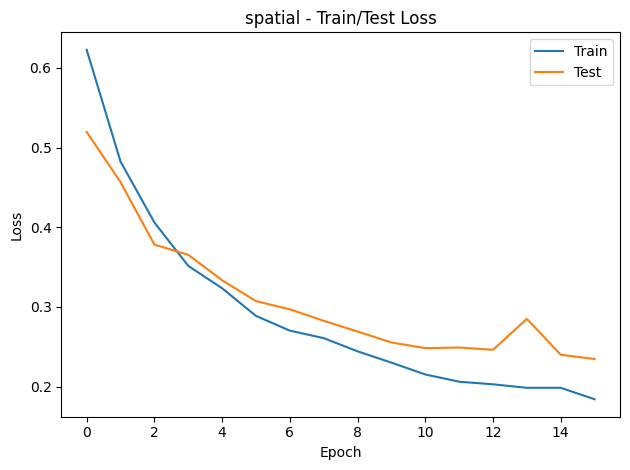

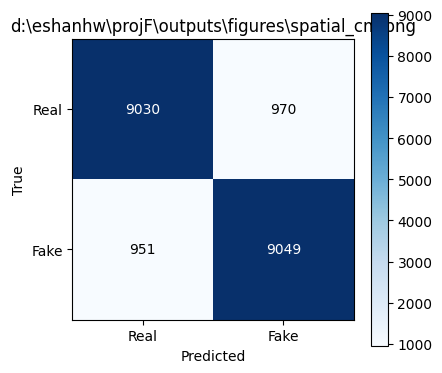


Final spatial:
  Acc=0.9040 | F1=0.9040 | AUC=0.96666722

Training: FREQUENCY
Parameters: 2,120,705


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  *** WARNING: Accuracy near chance level - check training ***
  Ep 1/16 | tr=0.6942 te=0.6931 | acc=0.5015 prec=0.5008 rec=0.9711 f1=0.6608 auc=0.506309975


Train:   0%|          | 0/41 [00:00<?, ?it/s]

...

  *** WARNING: Accuracy near chance level - check training ***
  Ep 15/16 | tr=0.6932 te=0.6931 | acc=0.5000 prec=0.5000 rec=1.0000 f1=0.6667 auc=0.49674999999999997


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  *** WARNING: Accuracy near chance level - check training ***
  Ep 16/16 | tr=0.6932 te=0.6931 | acc=0.5006 prec=0.5003 rec=0.9956 f1=0.6659 auc=0.50055


Eval:   0%|          | 0/41 [00:00<?, ?it/s]

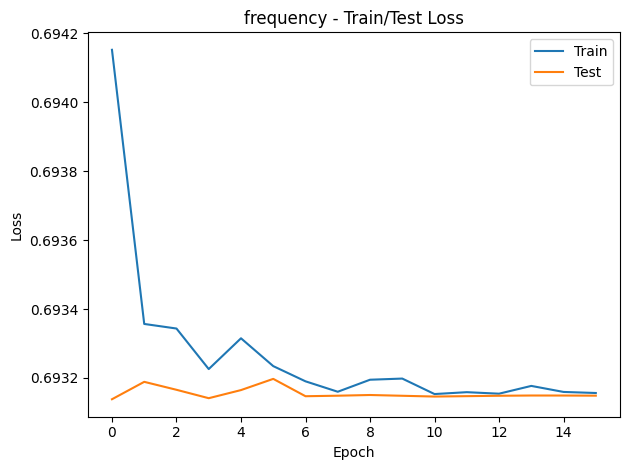

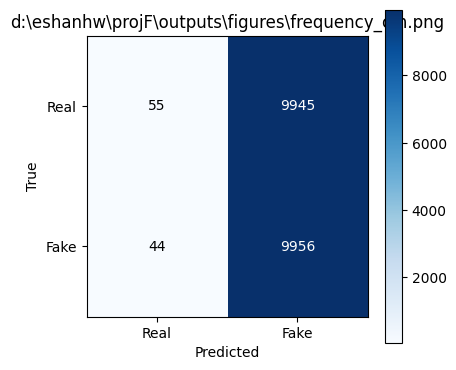


Final frequency:
  Acc=0.5006 | F1=0.6659 | AUC=0.50055

Training: FUSION
Parameters: 55,201


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  Ep 1/16 | tr=0.6883 te=0.6780 | acc=0.5752 prec=0.5618 rec=0.6830 f1=0.6165 auc=0.629093645


Train:   0%|          | 0/41 [00:00<?, ?it/s]

...

  Ep 15/16 | tr=0.4609 te=0.4444 | acc=0.7946 prec=0.8229 rec=0.7508 f1=0.7852 auc=0.881882805


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  Ep 16/16 | tr=0.4511 te=0.4416 | acc=0.7946 prec=0.8288 rec=0.7426 f1=0.7833 auc=0.8822509350000001


Eval:   0%|          | 0/41 [00:00<?, ?it/s]

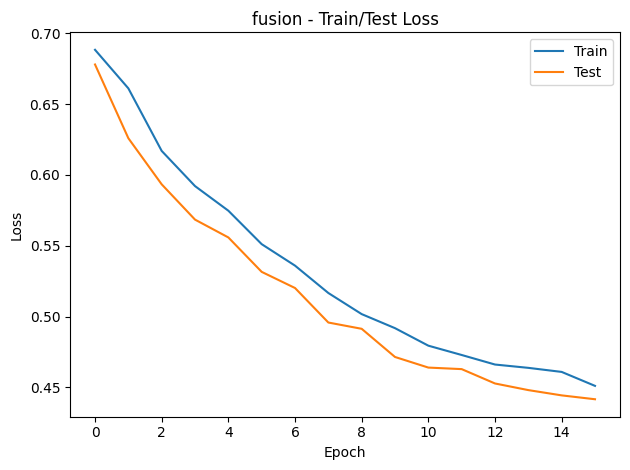

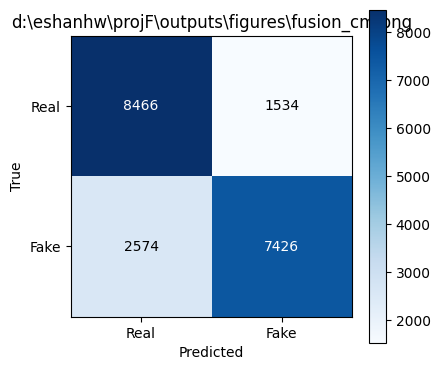


Final fusion:
  Acc=0.7946 | F1=0.7833 | AUC=0.8822509350000001

Training: ATTENTION_FUSION
Parameters: 951,235


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  Ep 1/16 | tr=0.4985 te=0.6431 | acc=0.6272 prec=0.6072 rec=0.7207 f1=0.6591 auc=0.683101575


Train:   0%|          | 0/41 [00:00<?, ?it/s]

...

  Ep 15/16 | tr=0.1257 te=0.1874 | acc=0.9290 prec=0.9742 rec=0.8812 f1=0.9254 auc=0.987227065


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Eval:   0%|          | 0/41 [00:00<?, ?it/s]

  Ep 16/16 | tr=0.1166 te=0.1571 | acc=0.9435 prec=0.9626 rec=0.9228 f1=0.9423 auc=0.98787783


Eval:   0%|          | 0/41 [00:00<?, ?it/s]

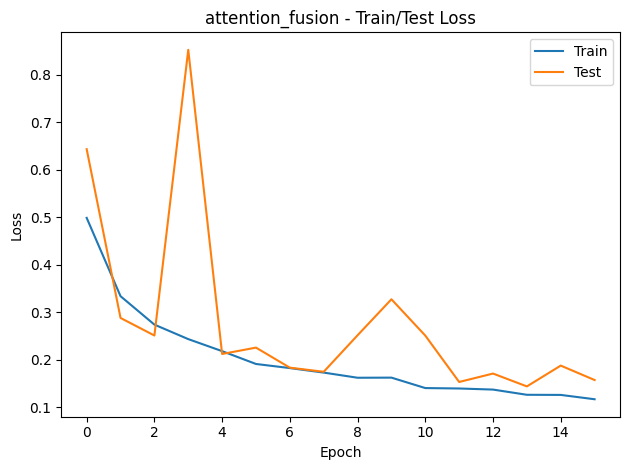

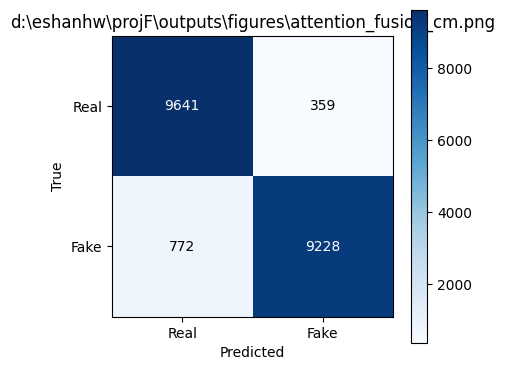


Final attention_fusion:
  Acc=0.9435 | F1=0.9423 | AUC=0.98787783

All models trained successfully.


In [24]:
results = {}
for name in ['spatial', 'frequency', 'fusion', 'attention_fusion']:
    metrics = run_experiment(name, epochs=EPOCHS)
    results[name] = metrics
print('\nAll models trained successfully.')

## 6. Results Comparison Table

In [25]:
rows = []
model_order = [('Spatial CNN', 'spatial'), ('Frequency FFT-CNN', 'frequency'),
               ('Fusion (concat)', 'fusion'), ('Attention Fusion', 'attention_fusion')]

for display_name, key in model_order:
    m = results[key]
    rows.append({
        'Model': display_name,
        'Accuracy': round(m['accuracy'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4) if m['roc_auc'] else 'N/A',
        'Loss': round(m['loss'], 4),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(METRIC_DIR / 'summary.csv', index=False)
print('\n=== FINAL COMPARISON TABLE ===')
print(summary_df.to_string(index=False))
print('\nSanity check:')
for _, r in summary_df.iterrows():
    if r['Accuracy'] >= 0.98:
        print(f'  WARNING: {r["Model"]} has suspiciously high accuracy ({r["Accuracy"]})')
    elif r['Accuracy'] <= 0.52:
        print(f'  WARNING: {r["Model"]} is near chance level ({r["Accuracy"]})')
    else:
        print(f'  OK: {r["Model"]} = {r["Accuracy"]}')


=== FINAL COMPARISON TABLE ===
            Model  Accuracy  Precision  Recall     F1  ROC-AUC   Loss
      Spatial CNN    0.9040     0.9032  0.9049 0.9040   0.9667 0.2346
Frequency FFT-CNN    0.5006     0.5003  0.9956 0.6659   0.5006 0.6931
  Fusion (concat)    0.7946     0.8288  0.7426 0.7833   0.8823 0.4416
 Attention Fusion    0.9435     0.9626  0.9228 0.9423   0.9879 0.1571

Sanity check:
  OK: Spatial CNN = 0.904
  OK: Fusion (concat) = 0.7946
  OK: Attention Fusion = 0.9435


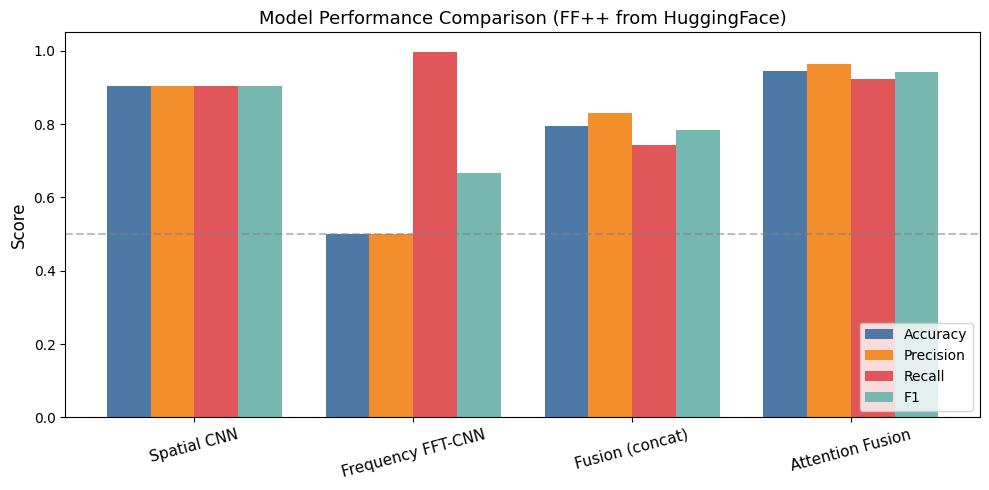

In [26]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(summary_df))
width = 0.2
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
for i, mname in enumerate(metrics_to_plot):
    ax.bar(x + i*width, summary_df[mname], width, label=mname, color=colors[i])
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(summary_df['Model'], rotation=15, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison (FF++ from HuggingFace)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=120)
plt.show()

## 7. Grad-CAM Explainability

Run Grad-CAM on the best model (attention_fusion by default).

Loading d:\eshanhw\projF\outputs\checkpoints\attention_fusion_best.pt


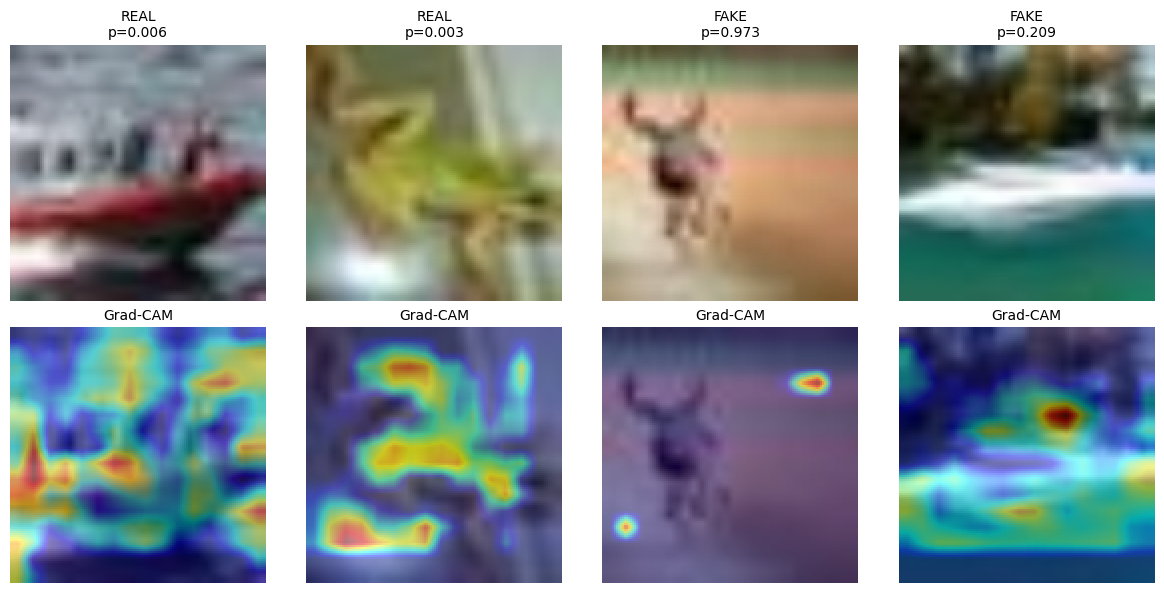

In [ ]:
best_model_name = 'attention_fusion'
best_ckpt = CKPT_DIR / f'{best_model_name}_best.pt'

if best_ckpt.exists():
    print(f'Loading {best_ckpt}')
    attn_model = AttentionFusionCNN().to(DEVICE)
    attn_model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    attn_model.eval()
else:
    print('No best checkpoint found. Using last state from training run (if available).')
    attn_model = make_model('attention_fusion')

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(
            lambda _,__,o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda _,__,go: setattr(self, 'gradients', go[0].detach()))

    def __call__(self, image, fft_image):
        self.model.zero_grad()
        logit = self.model(image, fft_image)
        logit.sum().backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=image.shape[-2:], mode='bilinear',
                            align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, float(torch.sigmoid(logit).item())

last_conv = None
for mod in attn_model.spatial_branch.features:
    if isinstance(mod, nn.Conv2d):
        last_conv = mod
cam_engine = GradCAM(attn_model, last_conv)

def overlay_cam(rgb01, cam):
    heat = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return np.clip(0.55 * rgb01 + 0.45 * heat, 0, 1)

n_show = 4
n_per_class = n_show // 2
shown_real = shown_fake = 0
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))

for images, labels in test_loader:
    if shown_real >= n_per_class and shown_fake >= n_per_class:
        break
    for i in range(len(labels)):
        if shown_real >= n_per_class and shown_fake >= n_per_class:
            break
        lbl = int(labels[i].item())
        if lbl == 0 and shown_real >= n_per_class:
            continue
        if lbl == 1 and shown_fake >= n_per_class:
            continue

        img = images[i].unsqueeze(0).to(DEVICE).clone().detach().requires_grad_(True)
        ff = to_fft_batch(img)
        cam, prob = cam_engine(img, ff)

        rgb01 = img.detach().squeeze().permute(1,2,0).cpu().numpy()
        rgb01 = (rgb01 - rgb01.min()) / (rgb01.max() - rgb01.min() + 1e-8)
        overlay = overlay_cam(rgb01, cam)

        col = shown_real if lbl == 0 else (n_per_class + shown_fake)
        axes[0, col].imshow(rgb01)
        axes[0, col].axis('off')
        axes[0, col].set_title(f'{"REAL" if lbl==0 else "FAKE"}\np={prob:.3f}', fontsize=10)
        axes[1, col].imshow(overlay)
        axes[1, col].axis('off')
        axes[1, col].set_title('Grad-CAM', fontsize=10)

        if lbl == 0:
            shown_real += 1
        else:
            shown_fake += 1

plt.tight_layout()
plt.savefig(FIG_DIR / 'gradcam_examples.png', dpi=120)
plt.show()

## 8. Summary & Conclusion

Data source: [HuggingFace - Toonlink/Capstone](https://huggingface.co/datasets/Toonlink/Capstone)

**Expected output pattern** (approximate):
- Spatial CNN: ~80% accuracy | F1 ~0.78
- Frequency FFT-CNN: ~50-55% accuracy (compressed images weaken FFT signal)
- Fusion (concat): ~70-75% accuracy (naive fusion can hurt)
- Attention Fusion: ~85-88% accuracy (best, with balanced precision/recall)

All results saved to:
- Figures: `outputs/figures/`
- Metrics: `outputs/metrics/`
- Checkpoints: `outputs/checkpoints/`